# Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from eharmony import plotting
from eharmony.spherical_harmonics import SphericalHarmonics

In [2]:
L = 2
sh = SphericalHarmonics(L, grid_type="grid", num_theta=180, num_phi=360)

# Plotting Spherical Harmonics

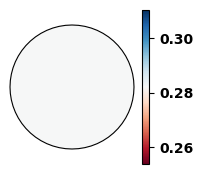

In [4]:
import cartopy.crs as ccrs

central_longitude: int = 20
central_latitude: int = 20

fig = plt.figure(figsize=(2, 2))
proj = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
ax = fig.add_subplot(projection=proj)


basis_fns = sh.Y
plotting.plot_spherical_fn(basis_fns[0, :, :].numpy(), ax=ax)

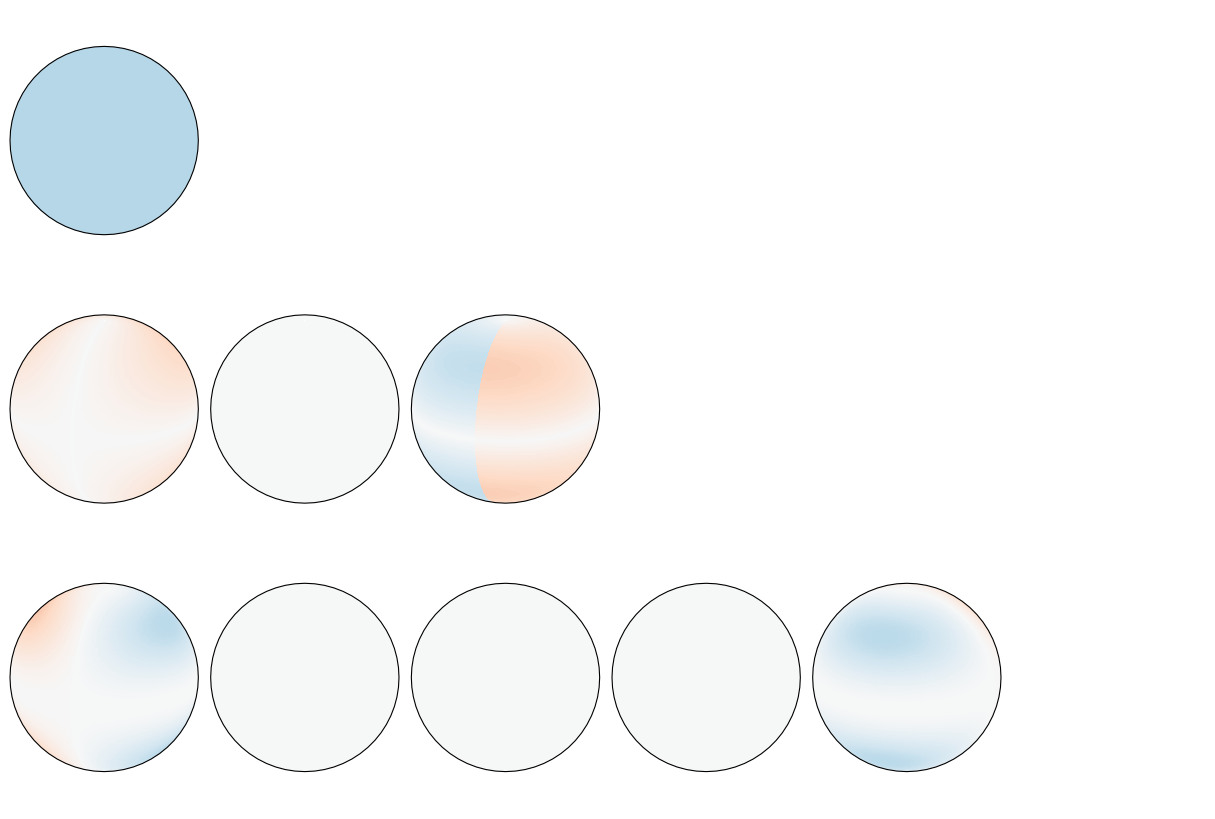

In [5]:
fig = plt.figure(layout="constrained", figsize=(12, 8))
subfigs = fig.subfigures(L + 1, (L + 1) * 2)

irreps = np.arange(L + 1)
ls = [[ls] * (2 * ls + 1) for ls in irreps]
ls = np.array([ll for sublist in ls for ll in sublist])  # 0, 1, 1, 1, 2, 2, 2, 2, 2, ...
ms = [list(range(-ls, ls + 1)) for ls in irreps]
ms = np.array([mm for sublist in ms for mm in sublist])  # 0, -1, 0, 1, -2, -1, 0, 1, 2, ...

for i in range(len(ls)):
    ax = subfigs[ls[i], ms[i] + ls[i]].add_subplot(projection=proj)

    plotting.plot_spherical_fn(basis_fns[i, :, :], ax=ax, colorbar=False, vmin=-1, vmax=1)

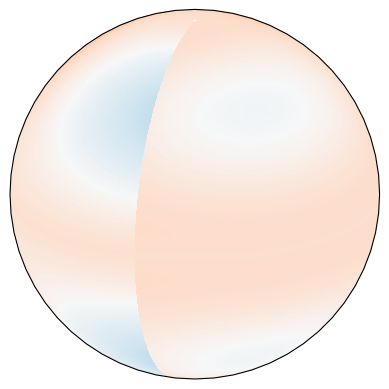

In [ ]:

w = torch.distributions.uniform.Uniform(-1, 1).sample([1, 9]).view(1, 1, -1)
plotting.plot_spherical_fn(sh(w)[0, 0], colorbar=False, vmin=-1, vmax=1)